# Импорты

In [1]:
# %pip install matplotlib
# %pip install pymatgen
# %pip install crystal_toolkit

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from pymatgen.core import Structure

from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.io.vasp import Incar

from pymatgen.symmetry.bandstructure import HighSymmKpath
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

In [4]:
import warnings

In [5]:
# Лицензия VASP прямо запрещает свободное распространение POTCAR-файлов
warnings.filterwarnings(
    "ignore",
    message="No POTCAR file with matching TITEL fields was found"
)

In [6]:
pd.set_option('display.float_format', '{:.2e}'.format)

In [7]:
Ni_start_structure = Structure.from_file("Ni/POSCAR")
Al_start_structure = Structure.from_file("Al/POSCAR")
Ni3Al_start_structure = Structure.from_file("Ni3Al/POSCAR")

Ni_optimized_structure = Structure.from_file("Ni/result/CONTCAR")
Al_optimized_structure = Structure.from_file("Al/result/CONTCAR")
Ni3Al_optimized_structure = Structure.from_file("Ni3Al/result/CONTCAR")

Ni_Outcar = Outcar("Ni/result/OUTCAR")
Al_Outcar = Outcar("Al/result/OUTCAR")
Ni3Al_Outcar = Outcar("Ni3Al/result/OUTCAR")

Ni_INCAR = Incar.from_file("Ni/INCAR")
Al_INCAR = Incar.from_file("Al/INCAR")
Ni3Al_INCAR = Incar.from_file("Ni3Al/INCAR")

Ni_01_vasprun = Vasprun("Ni/result/vasprun.xml")
Al_01_vasprun = Vasprun("Al/result/vasprun.xml")
Ni3Al_01_vasprun = Vasprun("Ni3Al/result/vasprun.xml")

# Параметры расчета

In [8]:
df_incar = pd.DataFrame({
    'Ni': dict(Ni_INCAR),
    'Al': dict(Al_INCAR),
    'Ni3Al': dict(Ni3Al_INCAR)
}).fillna('')

df_incar

,Ni,Al,Ni3Al
SYSTEM,Ni bulk fcc,Al bulk fcc,Ni3Al L12
PREC,Accurate,Accurate,Accurate
NCORE,4,4,4
LREAL,False,False,False
LWAVE,False,False,False
LASPH,True,True,True
ADDGRID,True,True,True
KSPACING,1.00e-01,1.00e-01,1.00e-01
SYMPREC,1.00e-05,1.00e-05,1.00e-05
ISYM,2,2,2


# Проверка сходимости электронного и ионного цикла

In [9]:
pd.set_option('display.float_format', '{:3}'.format)

df_stats = pd.DataFrame([{**outcar.run_stats, 'System': name} for name, outcar in [('Ni', Ni_Outcar), ('Al', Al_Outcar), ('Ni3Al', Ni3Al_Outcar)]])
df_stats

,Average memory used (kb),Maximum memory used (kb),Elapsed time (sec),System time (sec),User time (sec),Total CPU time used (sec),cores,System
0,None,122956.0,184.083,13.245,165.739,178.984,24,Ni
1,None,80876.0,21.892,1.436,20.205,21.641,24,Al
2,None,140384.0,329.6,27.159,294.641,321.8,24,Ni3Al


> Все три расчёта завершились штатно и сошлись, а не остановились из-за ограничения по числу шагов (NSW). Во всех случаях стартовые структуры (fcc Ni, fcc Al, L1₂ Ni₃Al) уже были близки к равновесным, поэтому релаксация потребовала лишь двух итераций, и ионы практически не смещались.

## Электронный цикл

In [10]:
Ni_steps = Ni_01_vasprun.ionic_steps
Al_steps = Al_01_vasprun.ionic_steps
Ni3Al_steps = Ni3Al_01_vasprun.ionic_steps

In [11]:
data = []
for name, steps in [('Ni', Ni_steps), ('Al', Al_steps), ('Ni3Al', Ni3Al_steps)]:
    es = steps[-1]['electronic_steps']
    for i in range(1, len(es)):
        d = abs(es[i]['e_fr_energy'] - es[i-1]['e_fr_energy'])
        data.append((name, i, d))

df_delta_e = pd.DataFrame(data, columns=['Система', 'Итерация', '|ΔE| (эВ)'])

df_delta_e.style.hide(axis='index').format({'|ΔE| (эВ)': '{:.10f}'})

Система,Итерация,|ΔE| (эВ)
Ni,1,0.0047500500
Ni,2,0.0023497600
Ni,3,0.0001496200
Ni,4,0.0000042300
Ni,5,0.0000015300
Ni,6,0.0000011900
Ni,7,0.0000006200
Ni,8,0.0000000400
Al,1,0.0000016900
Al,2,0.0000016000


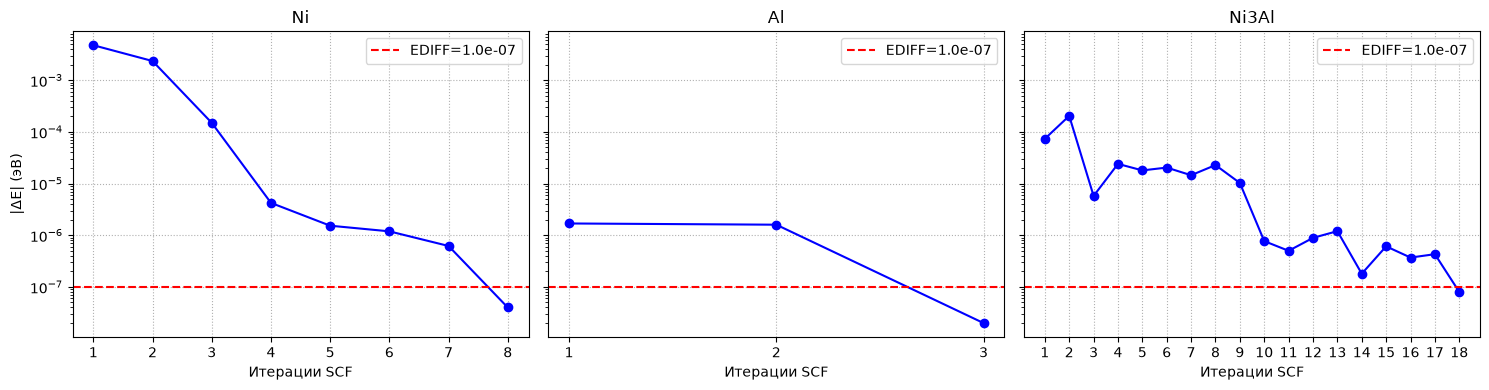

In [12]:
EDIFF = Ni_INCAR.get('EDIFF')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, ['Ni', 'Al', 'Ni3Al']):
    sub = df_delta_e[df_delta_e['Система'] == name]
    ax.plot(sub['Итерация'], sub['|ΔE| (эВ)'], 'o-', color='b')
    ax.axhline(EDIFF, color='r', linestyle='--', label=f'EDIFF={EDIFF:.1e}')
    ax.set_yscale('log')    
    ax.set_xlabel('Итерации SCF')
    ax.set_title(name)
    ax.grid(linestyle=':')
    ax.legend()
    max_iter = sub['Итерация'].max()
    ax.set_xticks(range(1, max_iter + 1))

axes[0].set_ylabel('|ΔE| (эВ)')
plt.tight_layout()
plt.show()

## Ионный цикл

In [13]:
data_ion_forces = []
for name, steps in [('Ni', Ni_steps), ('Al', Al_steps), ('Ni3Al', Ni3Al_steps)]:
    for i, step in enumerate(steps):
        forces = step['forces']
        max_force = max(abs(f) for atom in forces for f in atom)
        data_ion_forces.append({'Система': name, 'Ионный шаг': i, '|F_max| (эВ/Å)': max_force})

df_ion_forces = pd.DataFrame(data_ion_forces)
df_ion_forces

,Система,Ионный шаг,|F_max| (эВ/Å)
0,Ni,0,0.0
1,Ni,1,0.0
2,Ni,2,0.0
3,Al,0,0.0
4,Al,1,0.0
5,Al,2,0.0
6,Ni3Al,0,0.0
7,Ni3Al,1,0.0
8,Ni3Al,2,0.0


> **Примечание по ионной сходимости**     
> Расчёт содержал 3 ионных шага (шаг 0 — начальный SCF, шаги 1 и 2 — релаксация). Силы на все атомы практически нулевые на каждом шаге, поскольку стартовые структуры (fcc Ni, fcc Al, L1₂ Ni₃Al) заданы в позициях высокой симметрии, где силы обязаны быть нулевыми по симметрии. Расчёт сошёлся за 2 шага релаксации, ионы не двигались.

# Кристаллографические парамеры

In [14]:
# Начальный параметр решетки
Ni_a = Ni_start_structure.lattice.a
Al_a = Al_start_structure.lattice.a
Ni3Al_a = Ni3Al_start_structure.lattice.a

# Оптимизированный параметр решетки
Ni_a_opt = Ni_optimized_structure.lattice.a
Al_a_opt = Al_optimized_structure.lattice.a
Ni3Al_a_opt = Ni3Al_optimized_structure.lattice.a

# Начальный объем
Ni_volume = Ni_start_structure.volume
Al_volume = Al_start_structure.volume
Ni3Al_volume = Ni3Al_start_structure.volume

# Оптимизированный объем
Al_volume_opt = Al_optimized_structure.volume
Ni_volume_opt = Ni_optimized_structure.volume
Ni3Al_volume_opt = Ni3Al_optimized_structure.volume

# Пространственная группа
Ni_Space_Group = SpacegroupAnalyzer(Ni_optimized_structure, 0.1).get_space_group_symbol()
Al_Space_Group = SpacegroupAnalyzer(Al_optimized_structure, 0.1).get_space_group_symbol()
Ni3Al_Space_Group = SpacegroupAnalyzer(Ni3Al_optimized_structure, 0.1).get_space_group_symbol()


In [15]:
data_crystal = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'Группа': [Ni_Space_Group, Al_Space_Group, Ni3Al_Space_Group],
    'a старт. (Å)': [Ni_a, Al_a, Ni3Al_a],
    'a опт. (Å)': [Ni_a_opt, Al_a_opt, Ni3Al_a_opt],
    'Δa (%)': [(Ni_a_opt - Ni_a) / Ni_a * 100, 
               (Al_a_opt - Al_a) / Al_a * 100, 
               (Ni3Al_a_opt - Ni3Al_a) / Ni3Al_a * 100],
    'V старт. (Å³)': [Ni_volume, Al_volume, Ni3Al_volume],
    'V опт. (Å³)': [Ni_volume_opt, Al_volume_opt, Ni3Al_volume_opt],
    'ΔV (%)': [(Ni_volume_opt - Ni_volume) / Ni_volume * 100,
               (Al_volume_opt - Al_volume) / Al_volume * 100,
               (Ni3Al_volume_opt - Ni3Al_volume) / Ni3Al_volume * 100]
}

df_crystal = pd.DataFrame(data_crystal)
df_crystal

,Система,Группа,a старт. (Å),a опт. (Å),Δa (%),V старт. (Å³),V опт. (Å³),ΔV (%)
0,Ni,Fm-3m,3.52,3.5237548871960267,0.1066729317053034,43.614208,43.75393060319992,0.32036028993102666
1,Al,Fm-3m,4.05,4.038652061504626,-0.28019601223144774,66.43012499999999,65.87328448000343,-0.8382349423496576
2,Ni3Al,Pm-3m,3.57,3.568904653078676,-0.030681986591707525,45.499292999999994,45.457425587449116,-0.09201772113443318


# Магнитный момент

In [16]:
Al_total_mag = Al_Outcar.total_mag
Al_total_mag # None

In [17]:
Ni_total_mag = Ni_Outcar.total_mag
print("Ni:", Ni_total_mag, "μ_B")

Ni: 2.5077403 μ_B



**из INCAR для Ni:**
```VASP
ISPIN=2
MAGMOM=4*0.6
```

Получив для чистого никеля `total_mag = 2.5077 µ_B` (при стартовом `MAGMOM = 4×0.6 = 2.4 µ_B`), можно заключить, что система не только сохранила заданную намагниченность, но и увеличила её за счёт обменного взаимодействия. Финальное значение близко к экспериментальному (∼0.6 µ_B на атом Ni - [DOI:10.1103/PhysRev.138.A755](https://journals.aps.org/pr/abstract/10.1103/PhysRev.138.A755)), что подтверждает устойчивость ферромагнитного состояния в чистом Ni.

In [18]:
Ni3Al_total_mag = Ni3Al_Outcar.total_mag
print("Ni3Al:", Ni3Al_total_mag, "μ_B")

Ni3Al: 0.0001541 μ_B


**из INCAR для Ni3Al:**
```VASP
ISPIN=2
MAGMOM-0.0 3*0.2
```

Несмотря на то, что в INCAR был задан ISPIN=2 и начальные магнитные моменты `MAGMOM = 0.0 3*0.2` (для каждого атома Ni – 0.2 $μ_B$), итоговая суммарная намагниченность системы оказалась практически равной нулю (0.00015 µ_B). Это свидетельствует о том, что спонтанная спиновая поляризация в данной структуре отсутствует – расчёт привёл к немагнитному состоянию.

Такое поведение согласуется с литературными данными ([DOI:10.1016/j.intermet.2006.08.010](https://www.sciencedirect.com/science/article/abs/pii/S0966979506002548?via%3Dihub)) для объёмного Ni₃Al со структурой L1₂ – он действительно является слабомагнитным или парамагнитным при комнатных условиях.

In [19]:
Ni3Al_Outcar.magnetization

()

> **Примечание по локальным магнитным моментам**      
> Параметр LORBIT в VASP включает пост-обработку волновых функций для их разложения по локальным квантовым числам (l, m) в окрестности каждого иона. Это позволяет получить локальные свойства системы, такие как заряды и магнитные моменты на атомах. В нашем INCAR отсутствует тег LORBIT и поэтому кортеж `Ni3Al_Outcar.magnetization` - пуст.

# Полные энергии и энтальпия образования Ni3Al

In [20]:
# Полные энергии
TOTEN_Ni = Ni_Outcar.final_energy
TOTEN_Al = Al_Outcar.final_energy
TOTEN_Ni3Al = Ni3Al_Outcar.final_energy

print("Ni:", TOTEN_Ni, "эВ")
print("Al:", TOTEN_Al, "эВ")
print("Ni3Al:", TOTEN_Ni3Al, "эВ")

Ni: -22.28985347 эВ
Al: -14.98516409 эВ
Ni3Al: -22.1966028 эВ


In [21]:
# Изменение энтальпии образования, выраженное в электрон-вольтах на одну формульную единицу
dH_form_ev_per_fu = TOTEN_Ni3Al - (0.75*TOTEN_Ni+0.25*TOTEN_Al)

# Изменение энтальпии образования, выраженное в килоджоулях на моль формульных единиц
dH_form_kJ_per_mol_fu = dH_form_ev_per_fu*96.485

# Изменение энтальпии образования, выраженное в килоджоулях на моль атомов
dH_form_kJ_per_mol_atom = dH_form_kJ_per_mol_fu / 4

print(dH_form_ev_per_fu, "эВ")
print(dH_form_kJ_per_mol_fu, "кДж/моль формульных единиц")
print(dH_form_kJ_per_mol_atom, "кДж/моль атомов")

-1.732921675 эВ
-167.200947812375 кДж/моль формульных единиц
-41.80023695309375 кДж/моль атомов


## Изменение полной энергии в ходе ионной релаксации

In [22]:
df_energy_step = pd.DataFrame({
    'Ni': [s['e_0_energy'] for s in Ni_steps],
    'Al': [s['e_0_energy'] for s in Al_steps],
    'Ni3Al': [s['e_0_energy'] for s in Ni3Al_steps]
}).T
df_energy_step

,0,1,2
Ni,-22.2895925,-22.28958232,-22.28985347
Al,-14.98398113,-14.98514653,-14.98516409
Ni3Al,-22.19658512,-22.19660389,-22.1966028


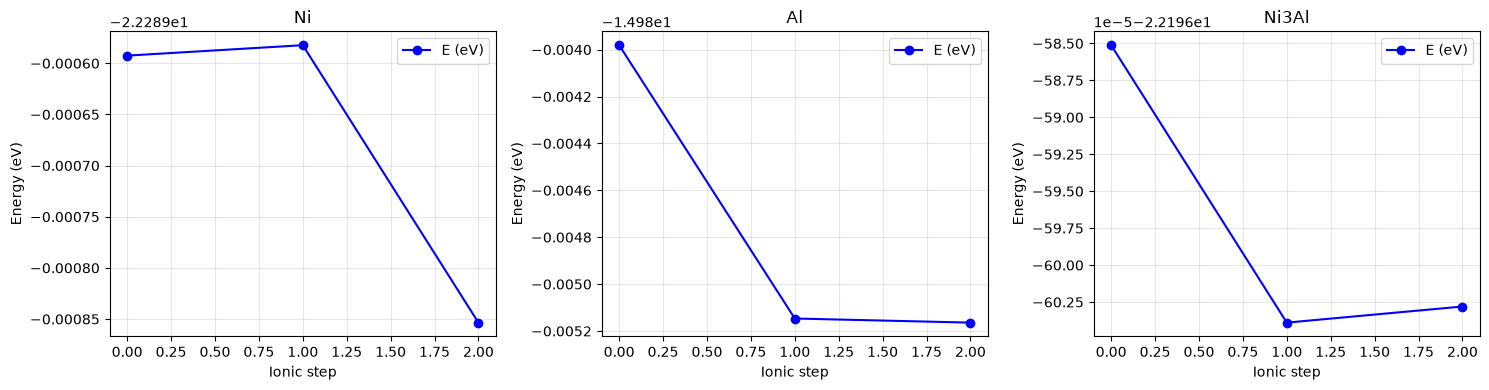

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, vrun) in enumerate([('Ni', Ni_01_vasprun), ('Al', Al_01_vasprun), ('Ni3Al', Ni3Al_01_vasprun)]):
    steps = vrun.ionic_steps
    if not steps:
        continue
    energies = [s['e_0_energy'] for s in steps]
    ax = axes[idx]
    ax.plot(range(len(energies)), energies, 'b-o', label='E (eV)')
    ax.set_xlabel('Ionic step')
    ax.set_ylabel('Energy (eV)')
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Вклады в полную энергию

In [24]:
contribs_Ni = Ni_Outcar.final_energy_contribs
contribs_Al = Al_Outcar.final_energy_contribs
contribs_Ni3Al = Ni3Al_Outcar.final_energy_contribs

data_energy_contribs = {
    'Ni': contribs_Ni,
    'Al': contribs_Al,
    'Ni3Al': contribs_Ni3Al
}

df_energy_contribs = pd.DataFrame(data_energy_contribs).T
df_energy_contribs

,PSCENC,TEWEN,DENC,EXHF,XCENC,PAW double counting,EENTRO,EBANDS,EATOM,Ediel_sol
Ni,368.66850081,-3747.19813782,-901.65911354,0.0,122.53249292,-274.02272220999976,-0.00872424,97.79252805,4311.60241449,0.0
Al,-0.81582378,-294.25131938,-0.42144913,0.0,-104.50311355,127.7697072,0.0008777,43.08205058,214.15419884,0.0
Ni3Al,218.752406,-2685.33898501,-862.32984628,0.0,66.3856262,-172.3222905900002,-0.01250932,125.42446585,3287.24036057,0.0


**Какие энергетические вклады доминируют в полной энергии Ni₃Al и как они сравниваются с чистыми металлами?**

**Ответ:**  
В таблице видно, что величины вкладов имеют порядок сотен – тысяч эВ, причём они сильно компенсируют друг друга. Самые большие по модулю:

| Вклад | Значение (эВ) |
|-------|---------------|
| `TEWEN` (ион-ион) | –2685.34 |
| `EATOM` (псевдоатом) | +3287.24 |
| `DENC` (электрон-электрон) | –862.33 | 
| `PSCENC` (компенсирующий фон) | +218.75 |


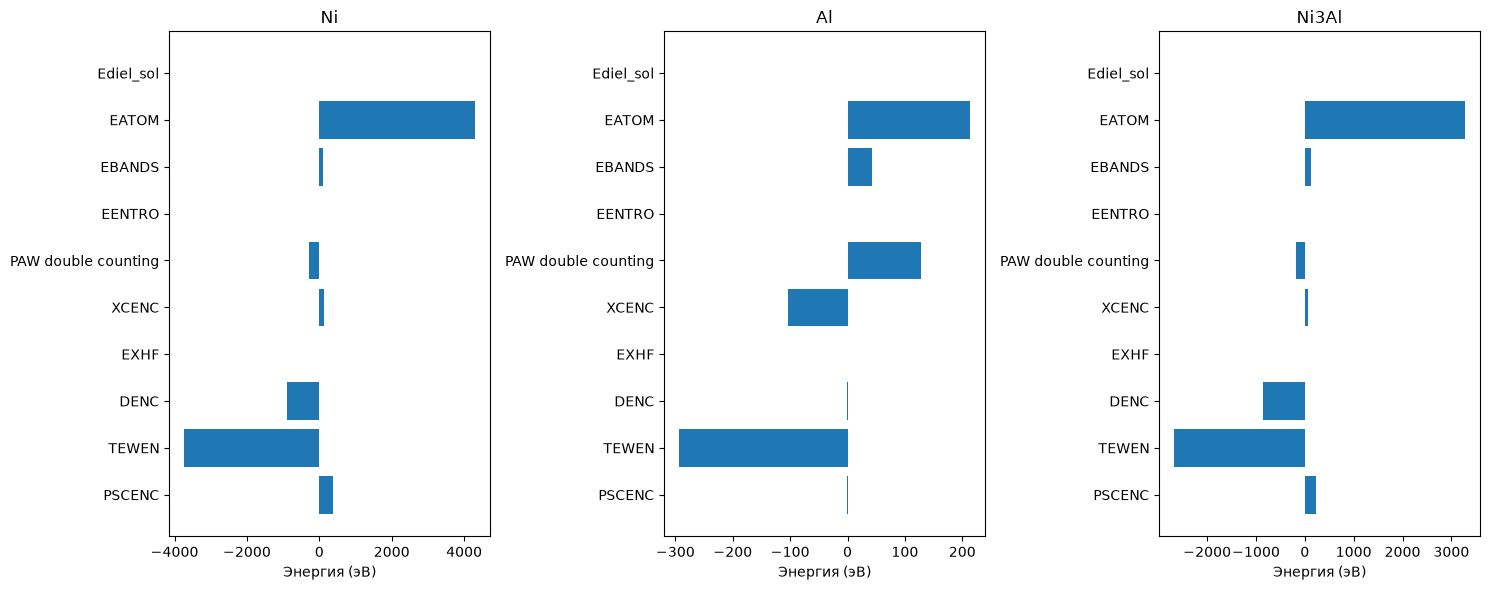

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, contribs, title in zip(axes, [contribs_Ni, contribs_Al, contribs_Ni3Al], ['Ni', 'Al', 'Ni3Al']):
    names = list(contribs.keys())
    values = list(contribs.values())
    ax.barh(names, values)
    ax.set_title(title)
    ax.set_xlabel('Энергия (эВ)')
    ax.tick_params(axis='y')

plt.tight_layout()
plt.show()

**Какие вклады энергии определяют стабильность Ni₃Al?**

**Ответ:**  
Рассчитаем разницу между Ni₃Al и взвешенной суммой чистых компонентов (0.75·Ni + 0.25·Al):

| Вклад | Δ (эВ) | Влияние на стабильность |
|-------|--------|--------------------------|
| **DENC** | –185.98 | Сильная стабилизация |
| **PSCENC** | –57.55 | Стабилизация |
| **TEWEN** | +198.62 | Сильная дестабилизация |
| **EBANDS** | +41.31 | Дестабилизация |
| XCENC | +0.61 | Почти нейтрально |
| PAW d.c. | +1.25 | Почти нейтрально |
| EENTRO | –0.006 | Пренебрежимо |

**Итог:** стабильность Ni₃Al (ΔH = –1.73 эВ) обеспечивается **прежде всего электростатическим вкладом DENC**, который более чем перекрывает дестабилизирующее действие TEWEN и EBANDS. Это указывает на **перераспределение заряда** и усиление ковалентно-металлических взаимодействий при образовании упорядоченной структуры L1₂.

---

 **Какой вклад энергии сильнее всего реагирует на изменение структуры при переходе от чистых металлов к Ni₃Al и почему?**

**Ответ:**  
Сильнее всего меняется TEWEN (ион-ионное взаимодействие): Δ = +198.6 эВ – это дестабилизация.  
Это связано с тем, что в структуре L1₂ атомы Ni и Al упорядочены, что изменяет расстояния между ионами и их электростатическое экранирование. Однако эта дестабилизация компенсируется DENC (–186 эВ) – перераспределением электронной плотности, которое уменьшает электрон-электронное отталкивание. Таким образом, электронная подсистема «подстраивается» под новую ионную конфигурацию, обеспечивая общий выигрыш в энергии.

#### Расшифровка названий вкладов

1. `PSCENC`: Энергия электростатического взаимодействия ионов с компенсирующим электронным газом.
2. `TEWEN:` Энергия Эвальда. Описывает межионное кулоновское взаимодействие (ион-ион).
3. `DENC:` Хартри-энергия (электрон-электронное взаимодействие). Вклад от кулоновского отталкивания электронов.
4. `EXHF:` Хартри-Фоковская обменная энергия. Этот член появляется только при использовании гибридных функционалов (например, PBE0 или HSE).
5. `XCENC:` Обменно-корреляционная энергия (V(xc)+E(xc)). Вклад от функционала (в нашем случае GGA).
6. `PAW double counting:` Поправка на двойной счет в методе PAW. Представлена двумя числами, которые в сумме дают общую поправку. Необходима для корректного перехода от псевдоволновых функций к полноволновым, чтобы избежать учета одних и тех же электронных взаимодействий дважды.
7. `EENTRO:` Энтропийный член (T*S). Возникает из-за использования метода размытия (ISMEAR) для металлических систем. Вклад, связанный с электронной энтропией.
8. `EBANDS:` Энергия, полученная из собственных значений Кона-Шэма. Сумма занятых электронных зон.
9. `EATOM:` Энергия псевдоатома в эталонной конфигурации, для которой был создан псевдопотенциал (POTCAR). Это опорная энергия, определенная в файле POTCAR.
10. `Ediel_Sol:` Энергия сольватации (влияния растворителя). Нулевое значение означает, что не была использована модель растворителя (VASPsol).

# K-точки

In [26]:
# Кол-во K-точек
Ni_N_KPOINTS = len(Ni_01_vasprun.actual_kpoints)
Al_N_KPOINTS = len(Al_01_vasprun.actual_kpoints)
Ni3Al_N_KPOINTS = len(Ni3Al_01_vasprun.actual_kpoints)

# Координаты первой k-точки по направлению
Ni_kx, Ni_ky, Ni_kz = Ni_01_vasprun.kpoints.kpts[0]
Al_kx, Al_ky, Al_kz = Al_01_vasprun.kpoints.kpts[0]
Ni3Al_kx, Ni3Al_ky, Ni3Al_kz = Ni3Al_01_vasprun.kpoints.kpts[0]

# K-cетка
Ni_kmesh = f"{Ni_kx}×{Ni_ky}×{Ni_kz}"
Al_kmesh = f"{Al_kx}×{Al_ky}×{Al_kz}"
Ni3Al_kmesh = f"{Ni3Al_kx}×{Ni3Al_ky}×{Ni3Al_kz}"

# Приводим к примитивной ячейке для корректного получения точек высокой симметрии (зона Бриллюэна задана для примитивной ячейки)
prim_Ni = SpacegroupAnalyzer(Ni_optimized_structure).get_primitive_standard_structure()
prim_Al = SpacegroupAnalyzer(Al_optimized_structure).get_primitive_standard_structure()
prim_Ni3Al = SpacegroupAnalyzer(Ni3Al_optimized_structure).get_primitive_standard_structure()

# K-точки высокой симметрии
Ni_hs_points = ', '.join(HighSymmKpath(prim_Ni).kpath['kpoints'].keys())
Al_hs_points = ', '.join(HighSymmKpath(prim_Al).kpath['kpoints'].keys())
Ni3Al_hs_points = ', '.join(HighSymmKpath(prim_Ni3Al).kpath['kpoints'].keys())

In [27]:
data_kpoints = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'N k-точек': [Ni_N_KPOINTS, Al_N_KPOINTS, Ni3Al_N_KPOINTS],
    'K-сетка': [Ni_kmesh, Al_kmesh, Ni3Al_kmesh],
    'Высокосимм. точки': [Ni_hs_points, Al_hs_points, Ni3Al_hs_points],
}

df_kpoints = pd.DataFrame(data_kpoints)
df_kpoints

,Система,N k-точек,K-сетка,Высокосимм. точки
0,Ni,220,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,165,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,220,18×18×18,"\Gamma, X, R, M"


# Плотность состояний (DOS)

In [28]:
Ni_nelect = int(Ni_Outcar.nelect)
Al_nelect = int(Al_Outcar.nelect)
Ni3Al_nelect = int(Ni3Al_Outcar.nelect)

# Кол-во электронов
print(f"Ni:  {Ni_nelect} электронов")
print(f"Al:  {Al_nelect} электронов")
print(f"Ni3Al: {Ni3Al_nelect} электронов")

Ni:  40 электронов
Al:  12 электронов
Ni3Al: 33 электронов


In [29]:
Ni_01_complete_dos = Ni_01_vasprun.complete_dos
Al_01_complete_dos = Al_01_vasprun.complete_dos
Ni3Al_01_complete_dos = Ni3Al_01_vasprun.complete_dos

Ni_complete_dos_energy = Ni_01_complete_dos.energies
Al_complete_dos_energy = Al_01_complete_dos.energies
Ni3Al_complete_dos_energy = Ni3Al_01_complete_dos.energies

Ni_complete_dos_densities = sum(Ni_01_complete_dos.densities.values())
Al_complete_dos_densities = sum(Al_01_complete_dos.densities.values())
Ni3Al_complete_dos_densities = sum(Ni3Al_01_complete_dos.densities.values())

Ni_01_efermi = Ni_01_vasprun.complete_dos.efermi
Al_01_efermi = Al_01_vasprun.complete_dos.efermi
Ni3Al_01_efermi = Ni3Al_01_vasprun.complete_dos.efermi

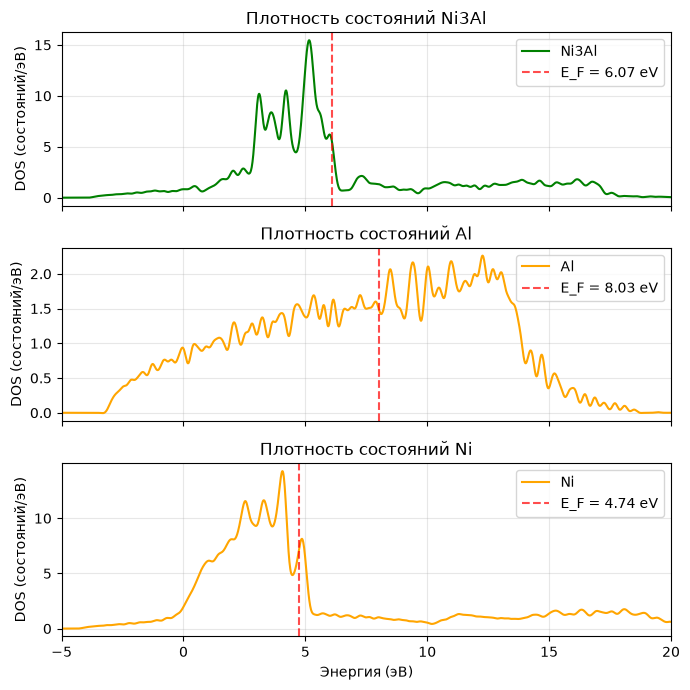

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# Ni3Al
axes[0].plot(Ni3Al_complete_dos_energy, Ni3Al_complete_dos_densities, color='green', label='Ni3Al')
axes[0].axvline(Ni3Al_01_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Ni3Al_01_efermi:.2f} eV')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Плотность состояний Ni3Al')

# Al
axes[1].plot(Al_complete_dos_energy, Al_complete_dos_densities, color='orange', label='Al')
axes[1].axvline(Al_01_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Al_01_efermi:.2f} eV')
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Плотность состояний Al')

# Ni
axes[2].plot(Ni_complete_dos_energy, Ni_complete_dos_densities, color='orange', label='Ni')
axes[2].axvline(Ni_01_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Ni_01_efermi:.2f} eV')
axes[2].set_xlabel('Энергия (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_title('Плотность состояний Ni')


plt.xlim(-5, 20)
plt.tight_layout()
plt.show()

<table>
  <tr>
    <td><img src="../image/image_04.png" width="500"></td>
    <td><img src="../image/image_05.png" width="500"></td>
  </tr>
</table>

**Левое изображение:** График зависимости полной и парциальной плотности состояний (DOS) для Al (алюминия) из работы *"Dielectric function of six elemental metals"* — [DOI: 10.1088/1742-6596/1890/1/012008](https://iopscience.iop.org/article/10.1088/1742-6596/1890/1/012008):  
Чёрная линия — полная DOS (TDOS), синяя — гибридизированные sp-электроны, красная — d-электроны.

**Правое изображение:** График зависимости полной плотности состояний (TDOS) для ферромагнитного (FM), антиферромагнитного (AFM) и немагнитного (NM) состояний никеля (Ni) из работы *"Ab-Initio Examination of Ni’s Stability, Electrical, Optical, and Magnetic Properties with GGA and GGA+U"* — [DOI: 10.25259/JQUS_15_2025](https://jqusci.com/ab-initio-examination-of-nis-stability-electrical-optical-and-magnetic-properties-with-gga-and-ggau/):  
Синий — FM, красный — AFM, зелёный — NM, для приближений GGA (A) и GGA+U (B).

# Сводная таблица

In [31]:
df_run1 = pd.DataFrame([
    {'Система': 'Ni', 'Электронов': Ni_nelect, 'E_F (эВ)': Ni_01_efermi, 'Магн. момент (μB)': Ni_total_mag, 'Полная энергия (эВ)': TOTEN_Ni},
    {'Система': 'Al', 'Электронов': Al_nelect, 'E_F (эВ)': Al_01_efermi, 'Магн. момент (μB)': Al_total_mag, 'Полная энергия (эВ)': TOTEN_Al},
    {'Система': 'Ni3Al', 'Электронов': Ni3Al_nelect, 'E_F (эВ)': Ni3Al_01_efermi, 'Магн. момент (μB)': Ni3Al_total_mag, 'Полная энергия (эВ)': TOTEN_Ni3Al},
])

df_run1 = df_run1.merge(df_crystal)
df_run1 = df_run1.merge(df_kpoints)
df_run1

,Система,Электронов,E_F (эВ),Магн. момент (μB),Полная энергия (эВ),Группа,a старт. (Å),a опт. (Å),Δa (%),V старт. (Å³),V опт. (Å³),ΔV (%),N k-точек,K-сетка,Высокосимм. точки
0,Ni,40,4.74267125,2.5077403,-22.28985347,Fm-3m,3.52,3.5237548871960267,0.1066729317053034,43.614208,43.75393060319992,0.32036028993102666,220,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,12,8.02817188,NaN,-14.98516409,Fm-3m,4.05,4.038652061504626,-0.28019601223144774,66.43012499999999,65.87328448000343,-0.8382349423496576,165,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,33,6.07223669,0.0001541,-22.1966028,Pm-3m,3.57,3.568904653078676,-0.030681986591707525,45.499292999999994,45.457425587449116,-0.09201772113443318,220,18×18×18,"\Gamma, X, R, M"
